# Reach direction and velocity tuning in macaque motor cortex

This notebook demonstrates the two classic encoding properties of primate motor
cortex during arm reaching, using data streamed from the DANDI Archive:

1. **Reach-direction tuning.** Individual units in primary motor cortex (M1) and
   dorsal premotor cortex (PMd) fire most strongly for reaches in one direction
   and least strongly for the opposite direction, with an approximately cosine
   dependence on reach angle (Georgopoulos et al., 1982).
2. **Velocity tuning.** The same units are not tuned to direction alone. Firing
   rate scales with movement speed, and the scaling is direction-dependent:
   faster movements toward the preferred direction drive proportionally larger
   responses, while faster movements in the opposite direction do not
   (Moran and Schwartz, 1999). The joint dependence on direction and speed is
   what "velocity tuning" means.

## Datasets

**Primary: DANDI 000128 (MC_Maze)**, monkey Jenkins, a delayed reaching task in
which the animal reaches to targets that are sometimes surrounded by virtual
barriers. The session contains 2295 trials, 182 sorted units recorded from
96-channel Utah arrays in M1 and PMd, and hand position and velocity sampled at
1 kHz. The 789 barrier-free trials are straight, near-center-out reaches and are
used for the trial-based direction analysis; the whole session is used for the
continuous velocity analysis.

**Replication: DANDI 000129 (MC_RTT)**, monkey Indy, a self-paced random-target
task with 130 M1 units and 649 s of continuous reaching. This is a different
animal, array, and task structure, and serves as an independent check.

Both dandisets were released with the Neural Latents Benchmark (Pei et al., 2021).
Files are streamed with `remfile` and a local disk cache; nothing is downloaded
in full. All analysis uses `pynapple` data structures, and the encoding models
are fit with `nemos`.

## Note on the recording-site labels

The MC_Maze electrode table lists 192 channels (96 PMd, 96 M1), but all 182
units index into the first 96 rows, so the array of origin cannot be recovered
from the file. The units are therefore treated as one motor-cortical population
throughout, and no M1-versus-PMd comparison is attempted.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)  # float32 leaves the Poisson fits short of tolerance

import IPython
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
import pynapple as nap
from tqdm import tqdm

import reachlib as rl

# Render figures in the notebook when running under a kernel. The inline backend
# is non-interactive, so this never opens a window; as a plain script the figures
# are only written to disk.
_ip = IPython.get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")

BIN = 0.02          # s, spike-count bin for the continuous analyses
SMOOTH_STD = 0.04   # s, symmetric Gaussian smoothing of the rate estimate
SPEED_MIN = 50.0    # mm/s, below this the movement direction is undefined
MIN_SPIKES = 300    # minimum spikes during movement for a unit to be analysed
N_FOLDS = 5

## 1. Load the session and validate every data stream

`reachlib.load_mc_maze` resolves the DANDI asset to its S3 URL, streams the NWB
file, and returns pynapple objects: a `TsGroup` of spike trains, `TsdFrame`s of
hand position and velocity, and an `IntervalSet` of the epochs during which
behaviour was actually sampled. Kinematics are only recorded inside trials, so
the timestamp vector contains gaps that must not be interpolated across; the
`IntervalSet` encodes exactly those contiguous stretches.

In [2]:
d = rl.load_mc_maze()
units, hand_pos, hand_vel, trials = d["units"], d["hand_pos"], d["hand_vel"], d["trials"]
epochs = d["epochs"]

print(units)
print("\nsession span %.0f s, %d behaviour epochs covering %.0f s"
      % (epochs.end[-1] - epochs.start[0], len(epochs), epochs.tot_length()))
print("trials: %d total, %d barrier-free" % (len(trials), int((trials.num_barriers == 0).sum())))
print("firing rates: median %.1f Hz, range %.2f-%.1f Hz"
      % (np.median(units.rate), units.rate.min(), units.rate.max()))
print("NaNs in hand velocity:", int(np.isnan(hand_vel.values).sum()))

note: unit-to-array assignment is not recoverable from this file; units are treated as one motor-cortical population.


  Index      rate  area
-------  --------  ------
      0   0.8536   M1/PMd
      1   0.95804  M1/PMd
      2   0.62812  M1/PMd
      3   0.22695  M1/PMd
      4   1.78315  M1/PMd
      5   0.57994  M1/PMd
      6   1.77419  M1/PMd
      7   1.8494   M1/PMd
      8   2.26614  M1/PMd
      9   0.16129  M1/PMd
     10   0.27352  M1/PMd
     11   1.98483  M1/PMd
     12   1.25683  M1/PMd
     13  10.0605   M1/PMd
     14   1.18088  M1/PMd
     15   1.52315  M1/PMd
     16   1.22657  M1/PMd
     17   6.94736  M1/PMd
     18   0.54439  M1/PMd
     19   0.71214  M1/PMd
     20   0.21917  M1/PMd
     21   0.66132  M1/PMd
     22   1.75627  M1/PMd
     23   3.25047  M1/PMd
     24   0.57671  M1/PMd
     25   0.4658   M1/PMd
     26   8.97508  M1/PMd
     27   3.10843  M1/PMd
     28   0.55262  M1/PMd
     29   0.15762  M1/PMd
     30   1.08423  M1/PMd
     31   0.72316  M1/PMd
     32   0.74505  M1/PMd
     33   5.43244  M1/PMd
     34  10.8743   M1/PMd
     35   0.89135  M1/PMd
     36   1.88

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(


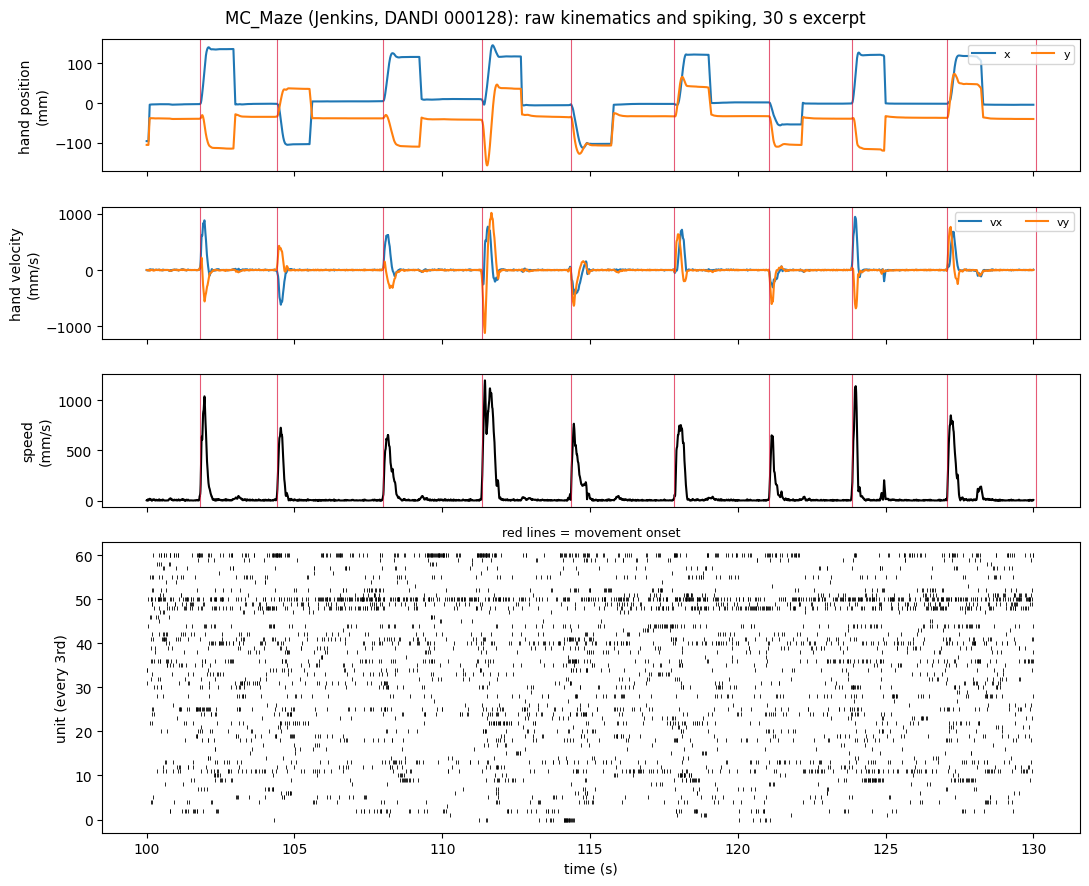

In [3]:
speed_full = nap.Tsd(t=hand_vel.t, d=np.hypot(*hand_vel.values.T),
                     time_support=hand_vel.time_support)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw=dict(height_ratios=[1, 1, 1, 2.2]))
win = nap.IntervalSet(start=100, end=130)
hp, hv, sp = hand_pos.restrict(win), hand_vel.restrict(win), speed_full.restrict(win)
axes[0].plot(hp.t, hp.values[:, 0], label="x")
axes[0].plot(hp.t, hp.values[:, 1], label="y")
axes[0].set_ylabel("hand position\n(mm)")
axes[0].legend(loc="upper right", ncol=2, fontsize=8)
axes[1].plot(hv.t, hv.values[:, 0], label="vx")
axes[1].plot(hv.t, hv.values[:, 1], label="vy")
axes[1].set_ylabel("hand velocity\n(mm/s)")
axes[1].legend(loc="upper right", ncol=2, fontsize=8)
axes[2].plot(sp.t, sp.values, color="k")
axes[2].set_ylabel("speed\n(mm/s)")
tr_win = trials[(trials.start_time > win.start[0]) & (trials.start_time < win.end[0])]
for ax in axes[:3]:
    for t in tr_win.move_onset_time:
        ax.axvline(t, color="crimson", lw=0.8, alpha=0.7)
for row, u in enumerate(np.arange(0, len(units), 3)):
    s = units[u].restrict(win).t
    axes[3].plot(s, np.full_like(s, row), "|", ms=3, color="k", mew=0.6)
axes[3].set_ylabel("unit (every 3rd)")
axes[3].set_xlabel("time (s)")
axes[3].set_title("red lines = movement onset", fontsize=9, pad=4)
fig.suptitle("MC_Maze (Jenkins, DANDI 000128): raw kinematics and spiking, 30 s excerpt")
fig.tight_layout()
fig.savefig("fig01_raw_data.png", dpi=150)

The reaches are discrete and ballistic: the hand sits still, makes a single
fast excursion of roughly 130 mm, and returns. Movement onset annotations line
up with the rise of the speed trace, so the trial table and the kinematics are
on a common clock.

## 2. Reach geometry

For the barrier-free trials, the reach direction is defined as the angle of the
hand displacement over the 400 ms following movement onset. Because these
trials have no obstacle, the hand travels essentially straight to the target,
so this is an unambiguous measure.

In [4]:
straight = trials[(trials.num_barriers == 0) & (trials.success == 1)].copy()
onset = straight.move_onset_time.values
go = straight.go_cue_time.values
target_on = straight.target_on_time.values

p0 = np.column_stack([np.interp(onset, hand_pos.t, hand_pos.values[:, k]) for k in range(2)])
p1 = np.column_stack([np.interp(onset + 0.4, hand_pos.t, hand_pos.values[:, k]) for k in range(2)])
disp = p1 - p0
theta = np.arctan2(disp[:, 1], disp[:, 0])
amp = np.hypot(*disp.T)

offsets = np.arange(-0.3, 0.71, 0.005)
prof = rl.peri_event_matrix(hand_vel.t, speed_full.values, onset, offsets)
peak_speed = prof[:, (offsets >= 0) & (offsets <= 0.4)].max(1)
print("%d straight successful trials, median amplitude %.0f mm, median peak speed %.0f mm/s"
      % (len(straight), np.median(amp), np.median(peak_speed)))
print("mean speed profile peaks %.0f ms after movement onset"
      % (1000 * offsets[prof.mean(0).argmax()]))

789 straight successful trials, median amplitude 128 mm, median peak speed 815 mm/s
mean speed profile peaks 125 ms after movement onset


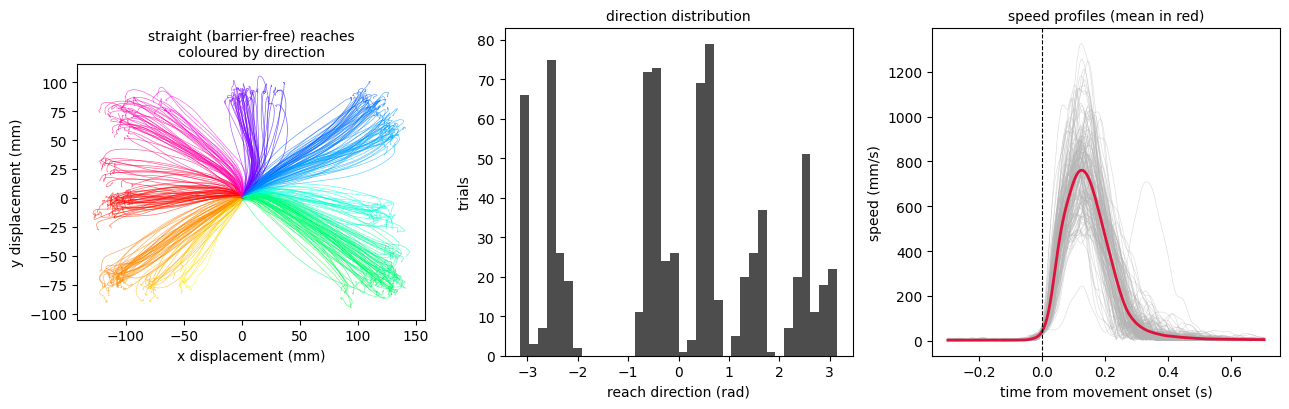

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
cmap = plt.get_cmap("hsv")
for i in range(0, len(onset), 2):
    seg = (hand_pos.t >= onset[i] - 0.05) & (hand_pos.t <= onset[i] + 0.6)
    p = hand_pos.values[seg]
    axes[0].plot(p[:, 0] - p[0, 0], p[:, 1] - p[0, 1],
                 color=cmap((theta[i] + np.pi) / (2 * np.pi)), lw=0.5, alpha=0.6)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x displacement (mm)")
axes[0].set_ylabel("y displacement (mm)")
axes[0].set_title("straight (barrier-free) reaches\ncoloured by direction", fontsize=10)
axes[1].hist(theta, bins=36, color="0.3")
axes[1].set_xlabel("reach direction (rad)")
axes[1].set_ylabel("trials")
axes[1].set_title("direction distribution", fontsize=10)
axes[2].plot(offsets, prof[::5].T, color="0.7", lw=0.4, alpha=0.5)
axes[2].plot(offsets, prof.mean(0), color="crimson", lw=2)
axes[2].axvline(0, color="k", ls="--", lw=0.8)
axes[2].set_xlabel("time from movement onset (s)")
axes[2].set_ylabel("speed (mm/s)")
axes[2].set_title("speed profiles (mean in red)", fontsize=10)
fig.tight_layout()
fig.savefig("fig02_reach_kinematics.png", dpi=150)

The trajectories fan out into the eight target directions, and the speed
profiles are the stereotyped bell shapes expected of point-to-point reaches.
Note that the eight clusters are not spaced exactly 45° apart, which matters
when trials are grouped into equal angular bins below.

## 3. Reach-direction tuning during movement and during the delay

Firing rate is measured in a movement window (-50 to +350 ms around movement
onset) and in a preparatory window (350 to 50 ms before the go cue, restricted
to trials with a delay longer than 400 ms). For each unit a cosine tuning curve

$$ r(\theta) = b_0 + b_1\cos\theta + b_2\sin\theta
            = b_0 + M\cos(\theta - \theta_{\mathrm{PD}}) $$

is fit by least squares, giving a preferred direction $\theta_{\mathrm{PD}}$ and
a modulation depth $M$. Significance is assessed by a permutation test that
shuffles the direction labels 1000 times.

In [6]:
spikes = [units[i].t for i in units.keys()]
mov_rate = rl.window_rates(spikes, onset - 0.05, onset + 0.35)
long_delay = (go - target_on) > 0.4
del_rate = rl.window_rates(spikes, go - 0.35, go - 0.05)

mov = rl.fit_cosine(theta, mov_rate)
dly = rl.fit_cosine(theta[long_delay], del_rate[long_delay])
_, mov_p = rl.cosine_permutation_test(theta, mov_rate, n_perm=1000)
_, dly_p = rl.cosine_permutation_test(theta[long_delay], del_rate[long_delay], n_perm=1000)
sig_mov, sig_dly = mov_p < 0.01, dly_p < 0.01

# A significant modulation depth does not guarantee a usable preferred
# direction. Splitting the trials in half and requiring the two PD estimates to
# agree within 45 degrees screens out units whose PD is dominated by noise.
rng = np.random.default_rng(0)
half = rng.permutation(len(theta)) < len(theta) // 2
pd_a = rl.fit_cosine(theta[half], mov_rate[half])["pd"]
pd_b = rl.fit_cosine(theta[~half], mov_rate[~half])["pd"]
reliable_mov = sig_mov & (np.abs(rl.circ_diff(pd_a, pd_b)) < np.pi / 4)

idx_d = np.flatnonzero(long_delay)
half_d = np.isin(np.arange(len(theta)), idx_d[rng.permutation(idx_d.size) < idx_d.size // 2])
pd_da = rl.fit_cosine(theta[half_d], del_rate[half_d])["pd"]
pd_db = rl.fit_cosine(theta[long_delay & ~half_d], del_rate[long_delay & ~half_d])["pd"]
reliable_dly = sig_dly & (np.abs(rl.circ_diff(pd_da, pd_db)) < np.pi / 4)

print("directionally tuned during movement: %d/%d (%.0f%%)"
      % (sig_mov.sum(), sig_mov.size, 100 * sig_mov.mean()))
print("directionally tuned during the delay: %d/%d (%.0f%%)"
      % (sig_dly.sum(), sig_dly.size, 100 * sig_dly.mean()))
print("PD reliable by split-half: movement %d, delay %d"
      % (reliable_mov.sum(), reliable_dly.sum()))
print("median single-trial cosine R2 among tuned units: %.2f" % np.median(mov["r2"][sig_mov]))

directionally tuned during movement: 152/182 (84%)
directionally tuned during the delay: 105/182 (58%)
PD reliable by split-half: movement 149, delay 101
median single-trial cosine R2 among tuned units: 0.11


trials per 45-degree bin: [160  38   2 204 167  51  58 109] -> bins used: [0 1 3 4 5 6 7]


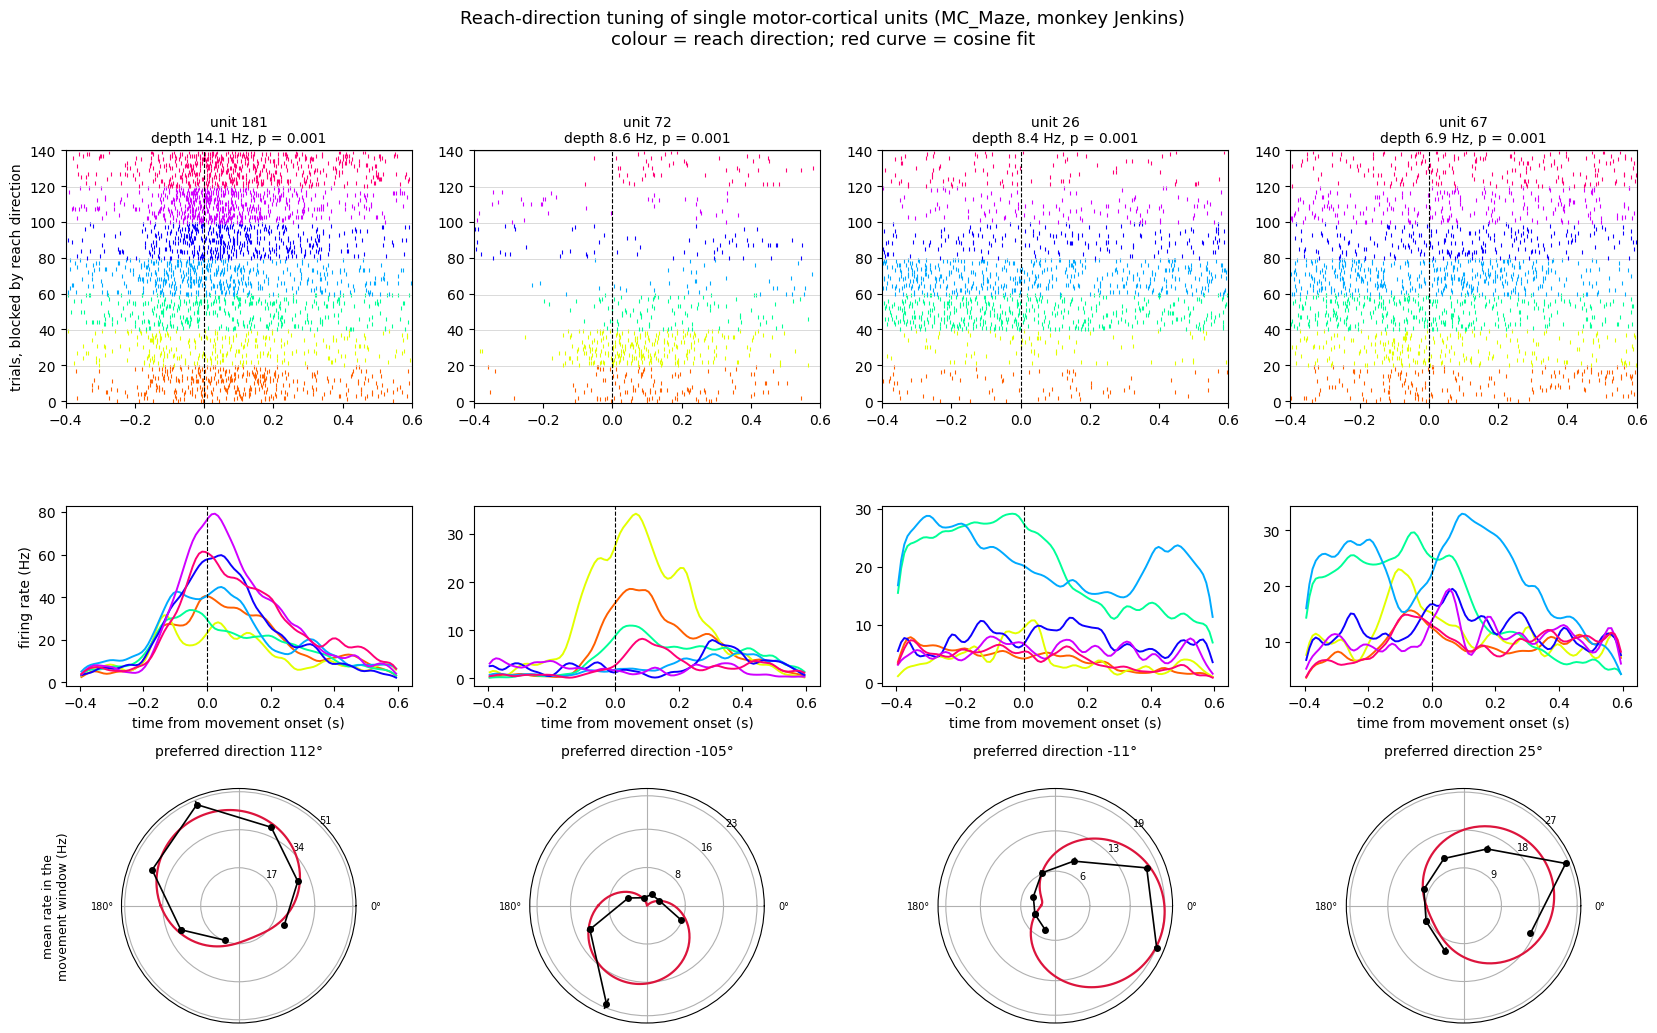

In [7]:
order = np.argsort(-mov["depth"] * sig_mov)
examples = order[[0, 1, 2, 4]]
edges = np.linspace(-np.pi, np.pi, 9)
bin_idx = np.digitize(theta, edges) - 1
bin_centres = (edges[:-1] + edges[1:]) / 2
n_per_bin = np.array([(bin_idx == b).sum() for b in range(8)])
use_bin = np.flatnonzero(n_per_bin >= 30)
print("trials per 45-degree bin:", n_per_bin, "-> bins used:", use_bin)

fig, axes = plt.subplots(3, len(examples), figsize=(4.2 * len(examples), 10.5),
                         gridspec_kw=dict(height_ratios=[1.4, 1, 1.3]))
psth_edges = np.arange(-0.4, 0.601, 0.01)
psth_t = psth_edges[:-1] + 0.005
kernel = np.exp(-0.5 * (np.arange(-6, 7) / 2.0) ** 2)
kernel /= kernel.sum()


def dir_colour(b):
    return cmap((bin_centres[b] + np.pi) / (2 * np.pi))


for col, u in enumerate(examples):
    st = spikes[u]
    ax = axes[0, col]
    row = 0
    for b in use_bin:
        for i in np.flatnonzero(bin_idx == b)[:20]:
            lo, hi = np.searchsorted(st, [onset[i] - 0.4, onset[i] + 0.6])
            s = st[lo:hi] - onset[i]
            ax.plot(s, np.full_like(s, row), "|", ms=3.5, mew=0.8, color=dir_colour(b))
            row += 1
        ax.axhline(row - 0.5, color="0.8", lw=0.5)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_xlim(-0.4, 0.6)
    ax.set_ylim(-1, row)
    ax.set_title("unit %d\ndepth %.1f Hz, p = %.3f" % (u, mov["depth"][u], mov_p[u]),
                 fontsize=10, pad=6)
    if col == 0:
        ax.set_ylabel("trials, blocked by reach direction")

    ax = axes[1, col]
    for b in use_bin:
        tr_idx = np.flatnonzero(bin_idx == b)
        c = np.zeros(psth_t.size)
        for i in tr_idx:
            lo, hi = np.searchsorted(st, [onset[i] + psth_edges[0], onset[i] + psth_edges[-1]])
            c += np.histogram(st[lo:hi] - onset[i], bins=psth_edges)[0]
        ax.plot(psth_t, np.convolve(c / (len(tr_idx) * 0.01), kernel, mode="same"),
                lw=1.4, color=dir_colour(b))
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("time from movement onset (s)")
    if col == 0:
        ax.set_ylabel("firing rate (Hz)")

    ax = fig.add_subplot(3, len(examples), 2 * len(examples) + col + 1, projection="polar")
    axes[2, col].axis("off")
    m = np.array([mov_rate[bin_idx == b, u].mean() for b in use_bin])
    se = np.array([mov_rate[bin_idx == b, u].std() / np.sqrt(n_per_bin[b]) for b in use_bin])
    th = bin_centres[use_bin]
    gap = np.diff(np.append(use_bin, use_bin[0] + 8)) > 1
    th_p, m_p, se_p = [], [], []
    for i in range(len(th)):
        th_p += [th[i]]
        m_p += [m[i]]
        se_p += [se[i]]
        if gap[i]:
            nxt = th[(i + 1) % len(th)] + (2 * np.pi if i == len(th) - 1 else 0)
            th_p += [(th[i] + nxt) / 2]
            m_p += [np.nan]
            se_p += [0.0]
    th_p += [th[0] + 2 * np.pi]
    m_p += [m[0] if not gap[-1] else np.nan]
    se_p += [se[0]]
    ax.errorbar(th_p, m_p, yerr=se_p, color="k", marker="o", ms=4, lw=1.2, zorder=3)
    fine = np.linspace(-np.pi, np.pi, 200)
    fit = mov["baseline"][u] + mov["depth"][u] * np.cos(rl.circ_diff(fine, mov["pd"][u]))
    ax.plot(fine, np.clip(fit, 0, None), color="crimson", lw=1.6)
    ax.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""])
    rmax = float(np.nanmax(m + se))
    ax.set_rticks(np.round(np.linspace(rmax / 3, rmax, 3), 0))
    ax.set_rlabel_position(45)
    ax.tick_params(labelsize=7)
    ax.set_title("preferred direction %.0f°" % np.degrees(mov["pd"][u]), fontsize=10, pad=24)
    if col == 0:
        ax.text(-0.28, 0.5, "mean rate in the\nmovement window (Hz)", transform=ax.transAxes,
                rotation=90, va="center", ha="center", fontsize=9)

fig.suptitle("Reach-direction tuning of single motor-cortical units "
             "(MC_Maze, monkey Jenkins)\ncolour = reach direction; red curve = cosine fit",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.945])
fig.savefig("fig03_example_direction_tuning.png", dpi=150)

The rasters and direction-resolved PSTHs show the effect directly: for each
unit one group of directions produces a large peri-movement burst and the
opposite group produces little or none. The polar plots show that a cosine
captures the shape of the tuning well.

PD circular concentration among reliable units: r = 0.138 (0 = uniform)
delay vs movement PD: median |shift| 67 deg (chance 90), 39% within 45 deg (chance 50%)


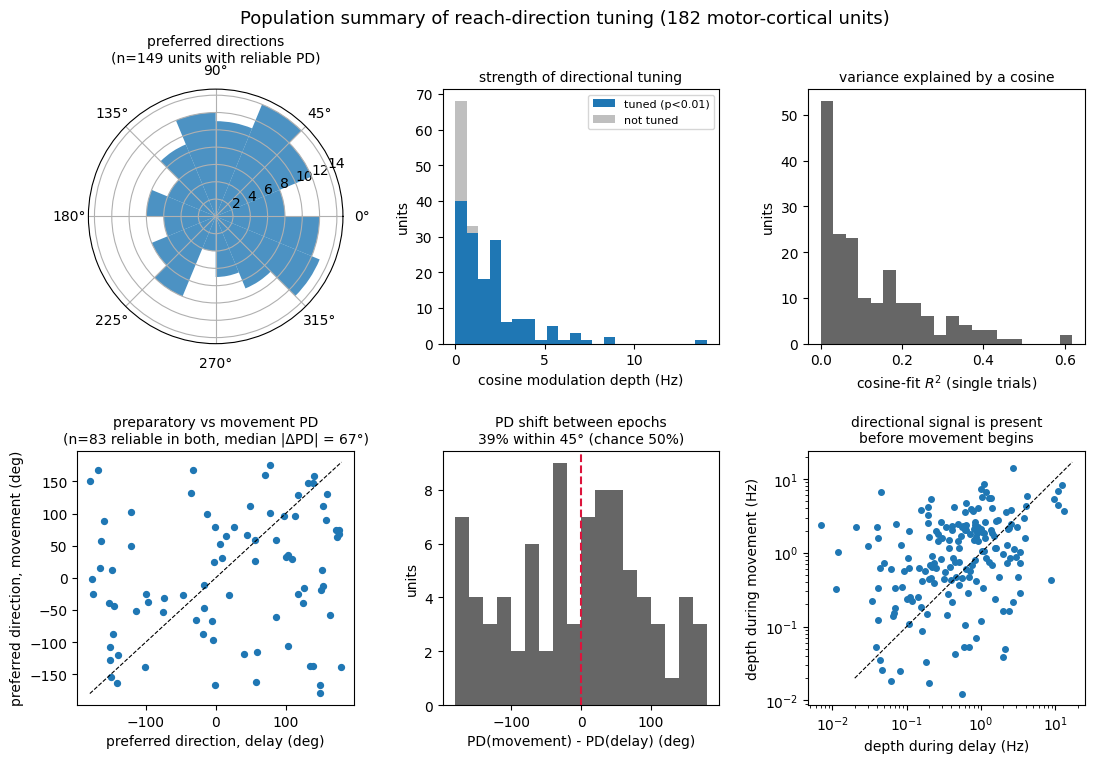

In [8]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.32)

ax = fig.add_subplot(gs[0, 0], projection="polar")
h, e = np.histogram(mov["pd"][reliable_mov], bins=np.linspace(-np.pi, np.pi, 17))
ax.bar(e[:-1], h, width=np.diff(e), align="edge", alpha=0.8, color="tab:blue")
ax.set_title("preferred directions\n(n=%d units with reliable PD)" % reliable_mov.sum(),
             fontsize=10, pad=20)

ax = fig.add_subplot(gs[0, 1])
dbins = np.histogram_bin_edges(mov["depth"], bins=22)
ax.hist([mov["depth"][sig_mov], mov["depth"][~sig_mov]], bins=dbins, stacked=True,
        color=["tab:blue", "0.75"], label=["tuned (p<0.01)", "not tuned"])
ax.set_xlabel("cosine modulation depth (Hz)")
ax.set_ylabel("units")
ax.set_title("strength of directional tuning", fontsize=10)
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 2])
ax.hist(mov["r2"], bins=20, color="0.4")
ax.axvline(np.median(mov["r2"]), color="crimson", ls="--")
ax.set_xlabel("cosine-fit $R^2$ (single trials)")
ax.set_ylabel("units")
ax.set_title("variance explained by a cosine", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
both = reliable_mov & reliable_dly
ax.scatter(np.degrees(dly["pd"][both]), np.degrees(mov["pd"][both]), s=18, color="tab:blue")
ax.plot([-180, 180], [-180, 180], "k--", lw=0.8)
dpd_all = rl.circ_diff(mov["pd"][both], dly["pd"][both])
med_shift = np.degrees(np.median(np.abs(dpd_all)))
frac45 = np.mean(np.abs(dpd_all) < np.pi / 4)
ax.set_xlabel("preferred direction, delay (deg)")
ax.set_ylabel("preferred direction, movement (deg)")
ax.set_title("preparatory vs movement PD\n(n=%d reliable in both, median |ΔPD| = %.0f°)"
             % (both.sum(), med_shift), fontsize=10)

ax = fig.add_subplot(gs[1, 1])
ax.hist(np.degrees(dpd_all), bins=np.arange(-180, 181, 20), color="0.4")
ax.axvline(0, color="crimson", ls="--")
ax.set_xlabel("PD(movement) - PD(delay) (deg)")
ax.set_ylabel("units")
ax.set_title("PD shift between epochs\n%.0f%% within 45° (chance 50%%)" % (100 * frac45),
             fontsize=10)

ax = fig.add_subplot(gs[1, 2])
ax.scatter(dly["depth"], mov["depth"], s=16, color="tab:blue")
ax.set_xscale("log")
ax.set_yscale("log")
lim = max(mov["depth"].max(), dly["depth"].max()) * 1.2
ax.plot([0.02, lim], [0.02, lim], "k--", lw=0.8)
ax.set_xlabel("depth during delay (Hz)")
ax.set_ylabel("depth during movement (Hz)")
ax.set_title("directional signal is present\nbefore movement begins", fontsize=10)

fig.suptitle("Population summary of reach-direction tuning (%d motor-cortical units)"
             % len(units), fontsize=13)
fig.savefig("fig04_population_direction_tuning.png", dpi=150, bbox_inches="tight")

circ_r = np.abs(np.exp(1j * mov["pd"][reliable_mov]).mean())
print("PD circular concentration among reliable units: r = %.3f (0 = uniform)" % circ_r)
print("delay vs movement PD: median |shift| %.0f deg (chance 90), %.0f%% within 45 deg "
      "(chance 50%%)" % (med_shift, 100 * frac45))

Most units are directionally tuned, preferred directions tile the workspace
roughly uniformly, and a directional signal is already present during the
delay period, before any movement. The preparatory and movement preferred
directions are related but far from identical: the median shift between the
two epochs is well below the 90° expected by chance, yet only a minority of
units fall within 45°. Preparatory activity is therefore not simply a scaled
preview of the movement response, which is consistent with the literature on
premotor delay activity.

## 4. Continuous velocity tuning

The trial-based analysis collapses each reach to a single angle. To see the
dependence on speed, the analysis is repeated on continuously sampled data:
spikes are binned at 20 ms, smoothed into a rate estimate, and regressed on the
instantaneous hand velocity. Because motor cortex leads the movement, the
velocity is sampled at a variable lag relative to the neural bin, and the lag
that maximises the fit is found by sweep. Bins where the hand is nearly still
are excluded, since direction is undefined there.

In [9]:
res = rl.continuous_velocity_tuning(units, hand_vel, epochs, bin_size=BIN,
                                    smooth_std=SMOOTH_STD, speed_min=SPEED_MIN,
                                    min_spikes=MIN_SPIKES)
uidx, keep_u = res["uidx"], res["keep_u"]
print("units analysed: %d/%d" % (keep_u.sum(), keep_u.size))
print("population-optimal lag: %+.0f ms (positive = neural activity leads)"
      % (1000 * res["pop_lag"]))
print("per-unit best lag: median %+.0f ms, IQR %+.0f to %+.0f ms"
      % (1000 * np.median(res["best_lag"]), *(1000 * np.percentile(res["best_lag"], [25, 75]))))
print("linear velocity model: median R2 = %.3f (max %.3f)"
      % (np.nanmedian(res["r2_lin"]), np.nanmax(res["r2_lin"])))

dpd = rl.circ_diff(mov["pd"][uidx][reliable_mov[uidx]], res["pd_cont"][reliable_mov[uidx]])
print("trial-based PD vs continuous PD: median |ΔPD| = %.0f° (chance 90°), %.0f%% within 45°"
      % (np.degrees(np.median(np.abs(dpd))), 100 * np.mean(np.abs(dpd) < np.pi / 4)))

units analysed: 159/182
population-optimal lag: +80 ms (positive = neural activity leads)
per-unit best lag: median +40 ms, IQR -140 to +140 ms
linear velocity model: median R2 = 0.021 (max 0.203)
trial-based PD vs continuous PD: median |ΔPD| = 31° (chance 90°), 64% within 45°


Occupancy over the velocity plane is strongly non-uniform, so the firing-rate
maps below are built explicitly as spike counts divided by dwell time per cell
rather than with a routine that assumes uniform sampling.

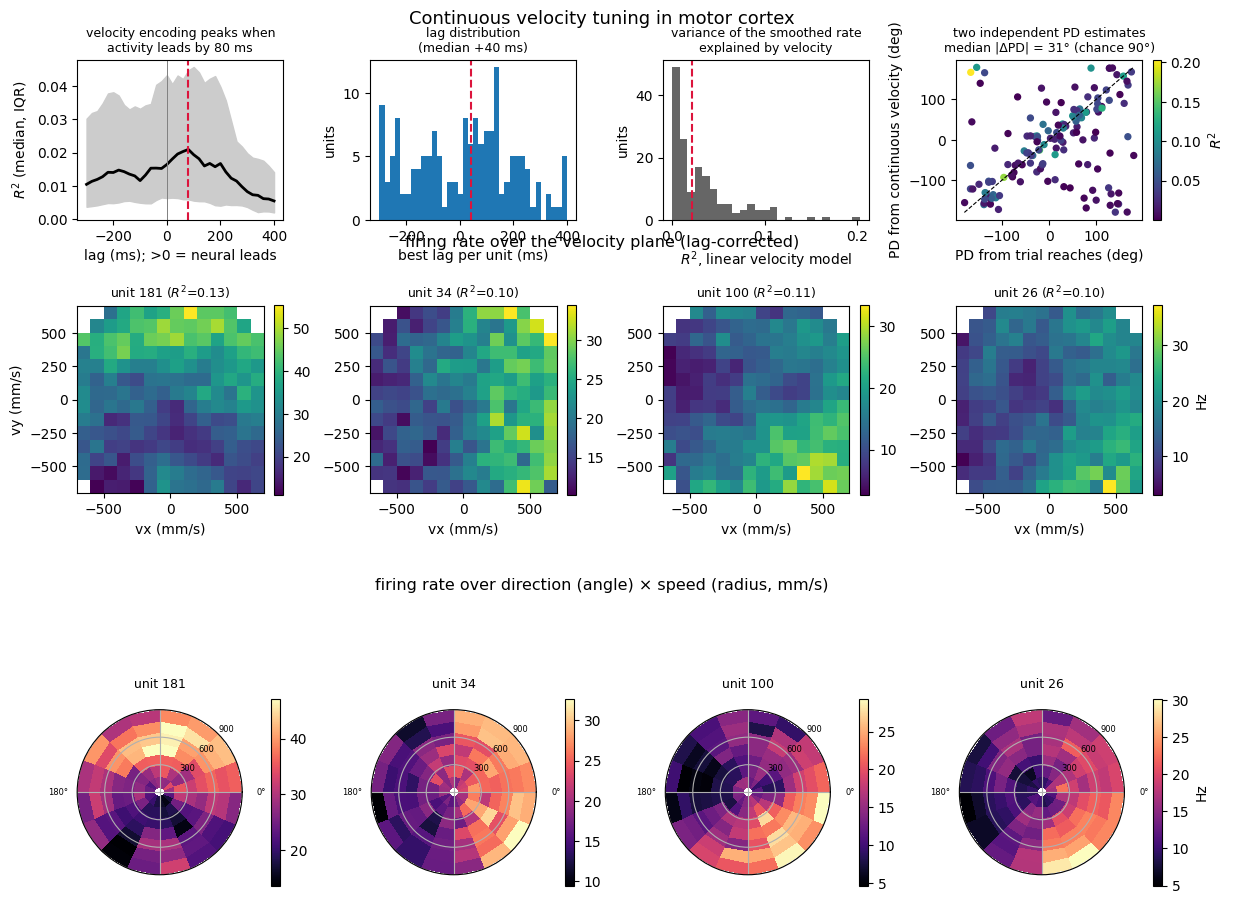

In [10]:
mask = res["mask"]
Cm = np.asarray(res["counts"].values)[mask][:, keep_u].astype(float)
speed_m = res["speed"][mask]
theta_m = res["theta"]

v_edges = np.linspace(-700, 700, 15)
tc_vel, occ_vel = rl.rate_map_2d(Cm, res["vx"][mask], res["vy"][mask], v_edges, v_edges,
                                 BIN, min_occupancy=30)
th_edges = np.linspace(-np.pi, np.pi, 17)
sp_edges = np.linspace(SPEED_MIN, 900, 8)
tc_ds, occ_ds = rl.rate_map_2d(Cm, theta_m, speed_m, th_edges, sp_edges, BIN, min_occupancy=30)

strong = np.argsort(-np.hypot(res["beta_lin"][1], res["beta_lin"][2]))[:4]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(1, 4, top=0.915, bottom=0.755, wspace=0.42)
gs_v = fig.add_gridspec(1, 4, top=0.715, bottom=0.435, wspace=0.42)
gs_p = fig.add_gridspec(1, 4, top=0.345, bottom=0.02, wspace=0.45)

ax = fig.add_subplot(gs[0])
ax.plot(1000 * res["lags"], res["pop_curve"], "k", lw=2)
q1, q3 = np.nanpercentile(res["r2_lag"], [25, 75], axis=1)
ax.fill_between(1000 * res["lags"], q1, q3, color="0.8")
ax.axvline(1000 * res["pop_lag"], color="crimson", ls="--")
ax.axvline(0, color="0.5", lw=0.7)
ax.set_xlabel("lag (ms); >0 = neural leads")
ax.set_ylabel("$R^2$ (median, IQR)")
ax.set_title("velocity encoding peaks when\nactivity leads by %d ms" % (1000 * res["pop_lag"]),
             fontsize=9)

ax = fig.add_subplot(gs[1])
ax.hist(1000 * res["best_lag"], bins=res["lags"].size, color="tab:blue")
ax.axvline(1000 * np.median(res["best_lag"]), color="crimson", ls="--")
ax.set_xlabel("best lag per unit (ms)")
ax.set_ylabel("units")
ax.set_title("lag distribution\n(median %+d ms)" % (1000 * np.median(res["best_lag"])),
             fontsize=9)

ax = fig.add_subplot(gs[2])
ax.hist(res["r2_lin"], bins=25, color="0.4")
ax.axvline(np.nanmedian(res["r2_lin"]), color="crimson", ls="--")
ax.set_xlabel("$R^2$, linear velocity model")
ax.set_ylabel("units")
ax.set_title("variance of the smoothed rate\nexplained by velocity", fontsize=9)

ax = fig.add_subplot(gs[3])
ok = reliable_mov[uidx]
sc = ax.scatter(np.degrees(mov["pd"][uidx][ok]), np.degrees(res["pd_cont"][ok]), s=18,
                c=res["r2_lin"][ok], cmap="viridis")
ax.plot([-180, 180], [-180, 180], "k--", lw=0.8)
ax.set_xlabel("PD from trial reaches (deg)")
ax.set_ylabel("PD from continuous velocity (deg)")
ax.set_title("two independent PD estimates\nmedian |ΔPD| = %.0f° (chance 90°)"
             % np.degrees(np.median(np.abs(dpd))), fontsize=9)
plt.colorbar(sc, ax=ax, fraction=0.046, label="$R^2$")

for col, u in enumerate(strong):
    ax = fig.add_subplot(gs_v[col])
    ax.imshow(tc_vel[:, :, u].T, origin="lower",
              extent=[v_edges[0], v_edges[-1], v_edges[0], v_edges[-1]],
              cmap="viridis", aspect="equal")
    ax.set_xlabel("vx (mm/s)")
    if col == 0:
        ax.set_ylabel("vy (mm/s)")
    ax.set_title("unit %d ($R^2$=%.2f)" % (uidx[u], res["r2_lin"][u]), fontsize=9)
    plt.colorbar(ax.images[0], ax=ax, fraction=0.046, label="Hz" if col == 3 else "")

for col, u in enumerate(strong):
    ax = fig.add_subplot(gs_p[col], projection="polar")
    T, S = np.meshgrid(th_edges, sp_edges, indexing="ij")
    pc = ax.pcolormesh(T, S, np.ma.masked_invalid(tc_ds[:, :, u]), cmap="magma", shading="flat")
    ax.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""])
    ax.set_rticks([300, 600, 900])
    ax.set_rlabel_position(45)
    ax.tick_params(labelsize=6)
    ax.set_title("unit %d" % uidx[u], fontsize=9, pad=16)
    plt.colorbar(pc, ax=ax, fraction=0.046, pad=0.14, label="Hz" if col == 3 else "")

fig.text(0.5, 0.728, "firing rate over the velocity plane (lag-corrected)",
         ha="center", fontsize=11.5)
fig.text(0.5, 0.385, "firing rate over direction (angle) × speed (radius, mm/s)",
         ha="center", fontsize=11.5)
fig.suptitle("Continuous velocity tuning in motor cortex", fontsize=13, y=0.965)
fig.savefig("fig05_velocity_fields.png", dpi=150)

The firing-rate maps over the velocity plane are graded along one axis rather
than peaked at a single velocity: rate rises smoothly as the hand moves faster
in the unit's preferred direction. Replotted in polar coordinates, direction
sets the angle of the gradient and speed sets how far the rate climbs along it.
The preferred direction recovered here, from continuous data across the whole
session, agrees with the one recovered from discrete trials.

## 5. Speed acts as a direction-dependent gain

If firing rate followed $b_0 + M\cos(\theta - \theta_{PD})\cdot|v|$, then speed
should increase the rate for movements toward the preferred direction and
decrease it for movements away from it. Sorting the movement bins by speed,
separately for directions within 45° of the preferred direction and directions
more than 135° away, tests exactly that.

In [11]:
centres, g_near, g_away = rl.speed_gain_curves(Cm, theta_m, speed_m, res["pd_cont"], BIN)
norm = np.nanmax(g_near, axis=1, keepdims=True)


def slope(g, x):
    ok = np.isfinite(g)
    return np.polyfit(x[ok], g[ok], 1)[0] if ok.sum() > 2 else np.nan


slope_near = np.array([slope(g, centres) for g in g_near])
slope_away = np.array([slope(g, centres) for g in g_away])
print("mean speed slope at the PD: %+.1f Hz per m/s; opposite the PD: %+.1f Hz per m/s"
      % (1000 * np.nanmean(slope_near), 1000 * np.nanmean(slope_away)))
print("the PD slope exceeds the anti-PD slope in %d/%d units"
      % (np.sum(slope_near > slope_away), len(slope_near)))

mean speed slope at the PD: +3.0 Hz per m/s; opposite the PD: -1.4 Hz per m/s
the PD slope exceeds the anti-PD slope in 138/159 units


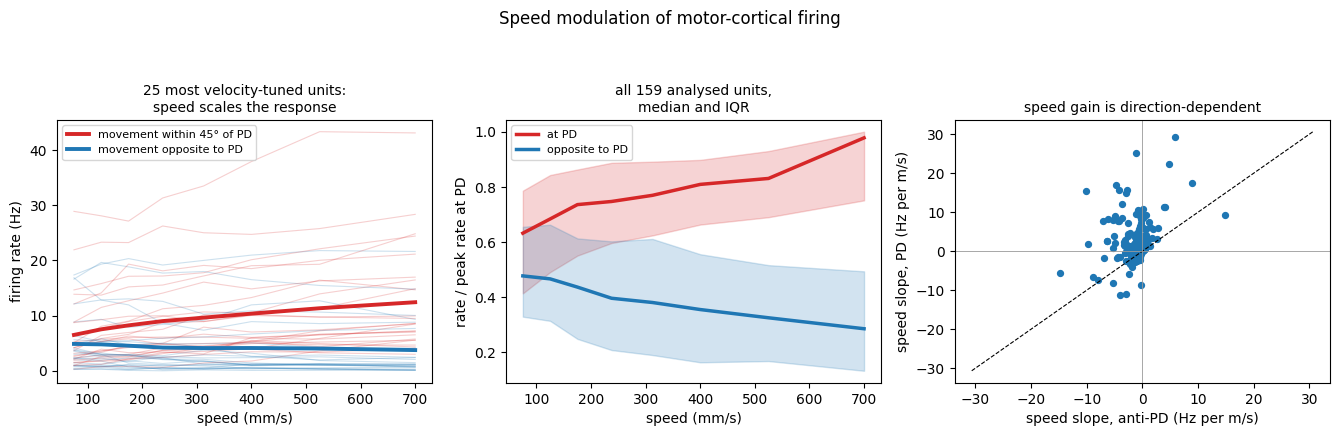

In [12]:
top = np.argsort(-np.nan_to_num(res["r2_lin"]))[:25]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
ax = axes[0]
for u in top:
    ax.plot(centres, g_near[u], color="tab:red", alpha=0.22, lw=0.8)
    ax.plot(centres, g_away[u], color="tab:blue", alpha=0.22, lw=0.8)
ax.plot(centres, np.nanmean(g_near[top], 0), color="tab:red", lw=2.8,
        label="movement within 45° of PD")
ax.plot(centres, np.nanmean(g_away[top], 0), color="tab:blue", lw=2.8,
        label="movement opposite to PD")
ax.set_xlabel("speed (mm/s)")
ax.set_ylabel("firing rate (Hz)")
ax.set_title("25 most velocity-tuned units:\nspeed scales the response", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
for g, c, lab in [(g_near / norm, "tab:red", "at PD"), (g_away / norm, "tab:blue",
                                                        "opposite to PD")]:
    ax.plot(centres, np.nanmedian(g, 0), color=c, lw=2.5, label=lab)
    lo, hi = np.nanpercentile(g, [25, 75], axis=0)
    ax.fill_between(centres, lo, hi, color=c, alpha=0.2)
ax.set_xlabel("speed (mm/s)")
ax.set_ylabel("rate / peak rate at PD")
ax.set_title("all %d analysed units,\nmedian and IQR" % keep_u.sum(), fontsize=10)
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(1000 * slope_away, 1000 * slope_near, s=18, color="tab:blue")
lim = 1000 * np.nanmax(np.abs(np.r_[slope_near, slope_away])) * 1.05
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
ax.axhline(0, color="0.6", lw=0.6)
ax.axvline(0, color="0.6", lw=0.6)
ax.set_xlabel("speed slope, anti-PD (Hz per m/s)")
ax.set_ylabel("speed slope, PD (Hz per m/s)")
ax.set_title("speed gain is direction-dependent", fontsize=10)
fig.suptitle("Speed modulation of motor-cortical firing", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("fig06_speed_gain.png", dpi=150)

## 6. Poisson GLMs: does speed add anything beyond direction?

The gain analysis above is descriptive. A cleaner test is to fit nested Poisson
GLMs with NeMoS and compare them on held-out data. Direction enters through a
cyclic B-spline basis and speed through a B-spline basis; the interaction model
uses their tensor product, which lets the whole tuning curve change shape with
speed. Cross-validation folds are contiguous blocks of trials, so no reach
contributes to both training and test data.

Speed is converted to m/s before it reaches the basis. In mm/s the spline
features are on the order of $10^{-3}$ and the penalised fit is badly
conditioned, which silently returns near-null models.

In [13]:
counts_all = res["counts"]
theta_glm = theta_m
sp_glm = speed_m / 1000.0
Y = Cm
trial_id = rl.epoch_index(epochs, np.asarray(counts_all.t)[mask])

dir_basis = nmo.basis.CyclicBSplineEval(n_basis_funcs=8, label="direction")
speed_basis = nmo.basis.BSplineEval(n_basis_funcs=5, label="speed")
designs = {
    "direction": (dir_basis, (theta_glm,)),
    "speed": (speed_basis, (sp_glm,)),
    "direction + speed": (dir_basis + speed_basis, (theta_glm, sp_glm)),
    "direction x speed": (dir_basis * speed_basis, (theta_glm, sp_glm)),
}
X = {name: np.asarray(b.compute_features(*args)) for name, (b, args) in designs.items()}
for k, v in X.items():
    print("%-20s %d features" % (k, v.shape[1]))


def poisson_deviance(y, mu):
    """Per-column Poisson deviance, with the y*log(y/mu) term defined at y=0."""
    mu = np.clip(mu, 1e-9, None)
    term = np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0.0)
    return 2 * (term - (y - mu)).sum(0)


fold = np.floor(N_FOLDS * trial_id / (trial_id.max() + 1)).astype(int)
pr2 = {name: np.zeros((N_FOLDS, Y.shape[1])) for name in X}
models = {}
for name in X:
    for f in tqdm(range(N_FOLDS), desc="GLM %s" % name):
        tr, te = fold != f, fold == f
        glm = nmo.glm.PopulationGLM(
            regularizer="Ridge", regularizer_strength=1e-4, solver_name="LBFGS",
            solver_kwargs={"tol": 1e-8, "maxiter": 1500},
        )
        glm.fit(X[name][tr], Y[tr])
        mu = np.asarray(glm.predict(X[name][te]))
        null = np.tile(Y[tr].mean(0), (te.sum(), 1))
        pr2[name][f] = 1 - poisson_deviance(Y[te], mu) / poisson_deviance(Y[te], null)
        if f == 0:
            models[name] = glm

pr2_mean = {k: v.mean(0) for k, v in pr2.items()}
print("\ncross-validated pseudo-R^2 (median over %d units)" % Y.shape[1])
for k, v in pr2_mean.items():
    print("  %-20s %.4f" % (k, np.median(v)))
gain = pr2_mean["direction x speed"] - pr2_mean["direction"]
print("direction x speed beats direction alone in %d/%d units (median gain %.4f)"
      % ((gain > 0).sum(), gain.size, np.median(gain)))

direction            8 features
speed                5 features
direction + speed    13 features
direction x speed    40 features


GLM direction:   0%|          | 0/5 [00:00<?, ?it/s]

GLM direction:  20%|██        | 1/5 [00:23<01:35, 24.00s/it]

GLM direction:  40%|████      | 2/5 [00:54<01:23, 27.69s/it]

GLM direction:  60%|██████    | 3/5 [01:27<01:00, 30.07s/it]

...

GLM direction x speed:  60%|██████    | 3/5 [02:01<01:24, 42.14s/it]

GLM direction x speed:  80%|████████  | 4/5 [02:50<00:45, 45.12s/it]

GLM direction x speed: 100%|██████████| 5/5 [03:41<00:00, 47.08s/it]

GLM direction x speed: 100%|██████████| 5/5 [03:41<00:00, 44.28s/it]


cross-validated pseudo-R^2 (median over 159 units)
  direction            0.0154
  speed                0.0038
  direction + speed    0.0215
  direction x speed    0.0293
direction x speed beats direction alone in 157/159 units (median gain 0.0086)


The GLM firing-rate surfaces are evaluated only over the well-sampled speed
range, since a tensor-product basis extrapolates unreliably into the sparse
tails of the speed distribution. The same example units are shown as in the
empirical velocity fields above, so the model and the data can be compared
directly.

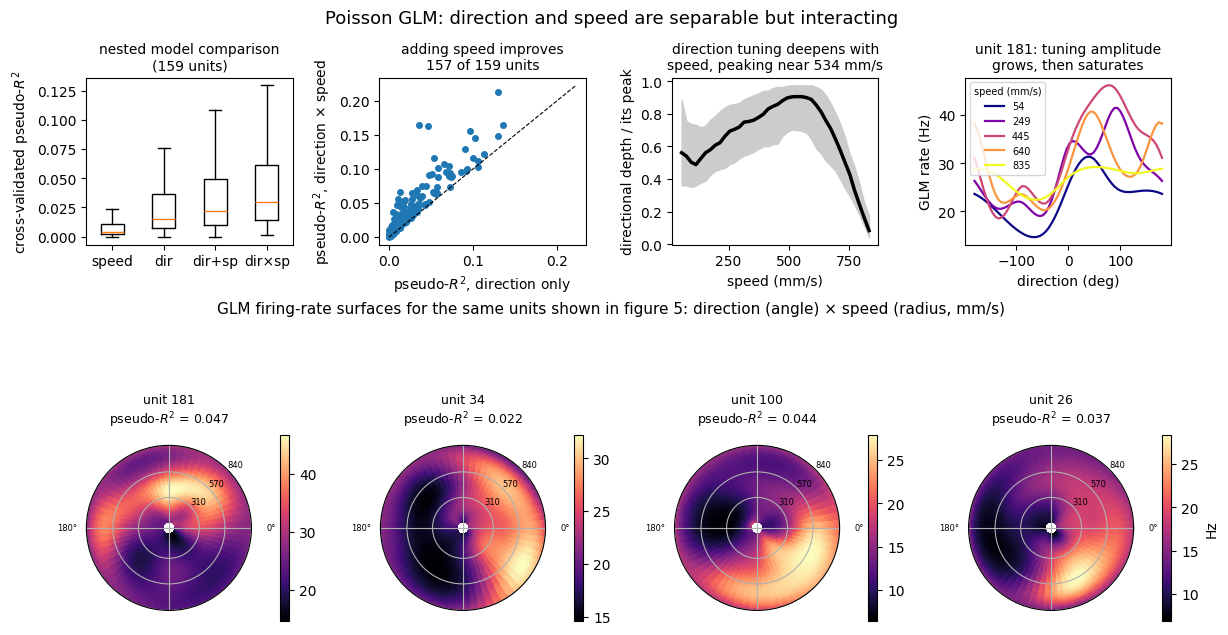

In [14]:
grid_th = np.linspace(-np.pi, np.pi, 64)
grid_sp = np.linspace(np.percentile(sp_glm, 2), np.percentile(sp_glm, 95), 40)
TH, SP = np.meshgrid(grid_th, grid_sp, indexing="ij")
Xg = np.asarray((dir_basis * speed_basis).compute_features(TH.ravel(), SP.ravel()))
rate_grid = (np.asarray(models["direction x speed"].predict(Xg)) / BIN).reshape(
    grid_th.size, grid_sp.size, -1)
examples_glm = strong  # same units as figure 5
Yn = Y.shape[1]

# Directional modulation depth of the fitted surfaces, as a function of speed.
depth_sp = rate_grid.max(0) - rate_grid.min(0)          # (n_speed, n_units)
depth_norm = depth_sp / depth_sp.max(0, keepdims=True)

fig = plt.figure(figsize=(14, 7.6))
gs = fig.add_gridspec(1, 4, top=0.855, bottom=0.635, wspace=0.42)
gs_p = fig.add_gridspec(1, 4, top=0.475, bottom=0.05, wspace=0.45)

ax = fig.add_subplot(gs[0])
order_m = ["speed", "direction", "direction + speed", "direction x speed"]
ax.boxplot([pr2_mean[k] for k in order_m],
           tick_labels=["speed", "dir", "dir+sp", "dir×sp"], showfliers=False)
ax.set_ylabel("cross-validated pseudo-$R^2$")
ax.set_title("nested model comparison\n(%d units)" % Yn, fontsize=10)

ax = fig.add_subplot(gs[1])
ax.scatter(pr2_mean["direction"], pr2_mean["direction x speed"], s=16, color="tab:blue")
lim = max(pr2_mean["direction x speed"].max(), pr2_mean["direction"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8)
ax.set_xlabel("pseudo-$R^2$, direction only")
ax.set_ylabel("pseudo-$R^2$, direction × speed")
ax.set_title("adding speed improves\n%d of %d units" % ((gain > 0).sum(), gain.size),
             fontsize=10)

ax = fig.add_subplot(gs[2])
ax.plot(1000 * grid_sp, np.median(depth_norm, 1), color="k", lw=2.5)
lo, hi = np.percentile(depth_norm, [25, 75], axis=1)
ax.fill_between(1000 * grid_sp, lo, hi, color="0.8")
ax.set_xlabel("speed (mm/s)")
ax.set_ylabel("directional depth / its peak")
pk = 1000 * grid_sp[np.median(depth_norm, 1).argmax()]
ax.set_title("direction tuning deepens with\nspeed, peaking near %d mm/s" % pk, fontsize=10)

ax = fig.add_subplot(gs[3])
u = examples_glm[0]
for j, s_val in enumerate(np.linspace(grid_sp[0], grid_sp[-1], 5)):
    k = np.argmin(np.abs(grid_sp - s_val))
    ax.plot(np.degrees(grid_th), rate_grid[:, k, u], lw=1.6,
            color=plt.get_cmap("plasma")(j / 4), label="%.0f" % (1000 * s_val))
ax.set_xlabel("direction (deg)")
ax.set_ylabel("GLM rate (Hz)")
ax.set_title("unit %d: tuning amplitude\ngrows, then saturates" % uidx[u], fontsize=10)
ax.legend(fontsize=7, title="speed (mm/s)", title_fontsize=7)

for col, u in enumerate(examples_glm):
    ax = fig.add_subplot(gs_p[col], projection="polar")
    th_e = np.linspace(-np.pi, np.pi, grid_th.size + 1)
    sp_e = np.linspace(grid_sp[0], grid_sp[-1], grid_sp.size + 1)
    T, S = np.meshgrid(th_e, sp_e, indexing="ij")
    pc = ax.pcolormesh(T, S, rate_grid[:, :, u], cmap="magma", shading="flat")
    ax.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""])
    ticks = np.round(np.linspace(grid_sp[0], grid_sp[-1], 4)[1:], 2)
    ax.set_rticks(ticks)
    ax.set_yticklabels(["%.0f" % (1000 * t) for t in ticks])
    ax.tick_params(labelsize=6)
    ax.set_rlabel_position(45)
    ax.set_title("unit %d\npseudo-$R^2$ = %.3f" % (uidx[u], pr2_mean["direction x speed"][u]),
                 fontsize=9, pad=16)
    plt.colorbar(pc, ax=ax, fraction=0.046, pad=0.14, label="Hz" if col == 3 else "")

fig.text(0.5, 0.545, "GLM firing-rate surfaces for the same units shown in figure 5: "
                     "direction (angle) × speed (radius, mm/s)", ha="center", fontsize=11)
fig.suptitle("Poisson GLM: direction and speed are separable but interacting",
             fontsize=13, y=0.945)
fig.savefig("fig07_glm_direction_speed.png", dpi=150)

The ordering of the nested models is unambiguous: speed alone explains little,
direction alone explains more, direction plus speed more still, and the
interaction model best of all. The interaction beats the direction-only model
for nearly every unit, which is the quantitative statement that these neurons
are tuned to velocity rather than to direction with a speed-independent gain.

## 7. Decoding hand velocity from the population

If direction and speed tuning are real, the movement should be recoverable from
the population. A ridge regression from population spike counts at lags of 0 to
200 ms onto instantaneous hand velocity, cross-validated over contiguous blocks
of trials, tests this directly.

In [15]:
DECODE_LAGS = np.arange(0, 0.201, 0.02)
C_all = np.asarray(counts_all.values, dtype=float)
tb = np.asarray(counts_all.t)
ep_id = rl.epoch_index(epochs, tb)
vx_b = np.interp(tb, hand_vel.t, hand_vel.values[:, 0])
vy_b = np.interp(tb, hand_vel.t, hand_vel.values[:, 1])

shifts = np.round(DECODE_LAGS / BIN).astype(int)
Xd = np.zeros((len(tb), C_all.shape[1] * len(shifts)))
valid = ep_id >= 0
for k, sh in enumerate(shifts):
    idx = np.arange(len(tb)) - sh
    ok = (idx >= 0) & (ep_id[np.clip(idx, 0, None)] == ep_id)
    Xd[ok, k * C_all.shape[1]:(k + 1) * C_all.shape[1]] = C_all[idx[ok]]
    valid &= ok

Xv, Yvv, ep_v = Xd[valid], np.column_stack([vx_b, vy_b])[valid], ep_id[valid]
fold_d = np.floor(N_FOLDS * ep_v / (ep_v.max() + 1)).astype(int)
pred = np.zeros_like(Yvv)
for f in tqdm(range(N_FOLDS), desc="ridge decoding"):
    tr, te = fold_d != f, fold_d == f
    mu_, sd_ = Xv[tr].mean(0), Xv[tr].std(0) + 1e-9
    A = (Xv[tr] - mu_) / sd_
    W = np.linalg.solve(A.T @ A + 1e3 * np.eye(A.shape[1]), A.T @ (Yvv[tr] - Yvv[tr].mean(0)))
    pred[te] = ((Xv[te] - mu_) / sd_) @ W + Yvv[tr].mean(0)

r2_dec = 1 - ((Yvv - pred) ** 2).sum(0) / ((Yvv - Yvv.mean(0)) ** 2).sum(0)
sp_true, sp_pred = np.hypot(*Yvv.T), np.hypot(*pred.T)
moving_bins = sp_true > 100
ang_err = rl.circ_diff(np.arctan2(pred[moving_bins, 1], pred[moving_bins, 0]),
                       np.arctan2(Yvv[moving_bins, 1], Yvv[moving_bins, 0]))
r_speed = np.corrcoef(sp_true, sp_pred)[0, 1]
print("cross-validated decoding R2: vx %.3f, vy %.3f" % tuple(r2_dec))
print("speed correlation r = %.3f" % r_speed)
print("direction error: median %.0f deg, %.0f%% within 45 deg"
      % (np.degrees(np.median(np.abs(ang_err))), 100 * np.mean(np.abs(ang_err) < np.pi / 4)))

ridge decoding:   0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_74366/3669784061.py:24: RuntimeWarning: divide by zero encountered in matmul
  W = np.linalg.solve(A.T @ A + 1e3 * np.eye(A.shape[1]), A.T @ (Yvv[tr] - Yvv[tr].mean(0)))
/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_74366/3669784061.py:24: RuntimeWarning: overflow encountered in matmul
  W = np.linalg.solve(A.T @ A + 1e3 * np.eye(A.shape[1]), A.T @ (Yvv[tr] - Yvv[tr].mean(0)))
/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_74366/3669784061.py:24: RuntimeWarning: invalid value encountered in matmul
  W = np.linalg.solve(A.T @ A + 1e3 * np.eye(A.shape[1]), A.T @ (Yvv[tr] - Yvv[tr].mean(0)))


/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_74366/3669784061.py:25: RuntimeWarning: divide by zero encountered in matmul
  pred[te] = ((Xv[te] - mu_) / sd_) @ W + Yvv[tr].mean(0)
/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_74366/3669784061.py:25: RuntimeWarning: overflow encountered in matmul
  pred[te] = ((Xv[te] - mu_) / sd_) @ W + Yvv[tr].mean(0)
/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_74366/3669784061.py:25: RuntimeWarning: invalid value encountered in matmul
  pred[te] = ((Xv[te] - mu_) / sd_) @ W + Yvv[tr].mean(0)
ridge decoding:  20%|██        | 1/5 [00:20<01:21, 20.46s/it]

ridge decoding:  40%|████      | 2/5 [00:44<01:07, 22.36s/it]

ridge decoding:  60%|██████    | 3/5 [01:01<00:39, 19.93s/it]

ridge decoding:  80%|████████  | 4/5 [01:24<00:21, 21.30s/it]

ridge decoding: 100%|██████████| 5/5 [01:43<00:00, 20.41s/it]

ridge decoding: 100%|██████████| 5/5 [01:43<00:00, 20.68s/it]

cross-validated decoding R2: vx 0.564, vy 0.552
speed correlation r = 0.837
direction error: median 17 deg, 86% within 45 deg


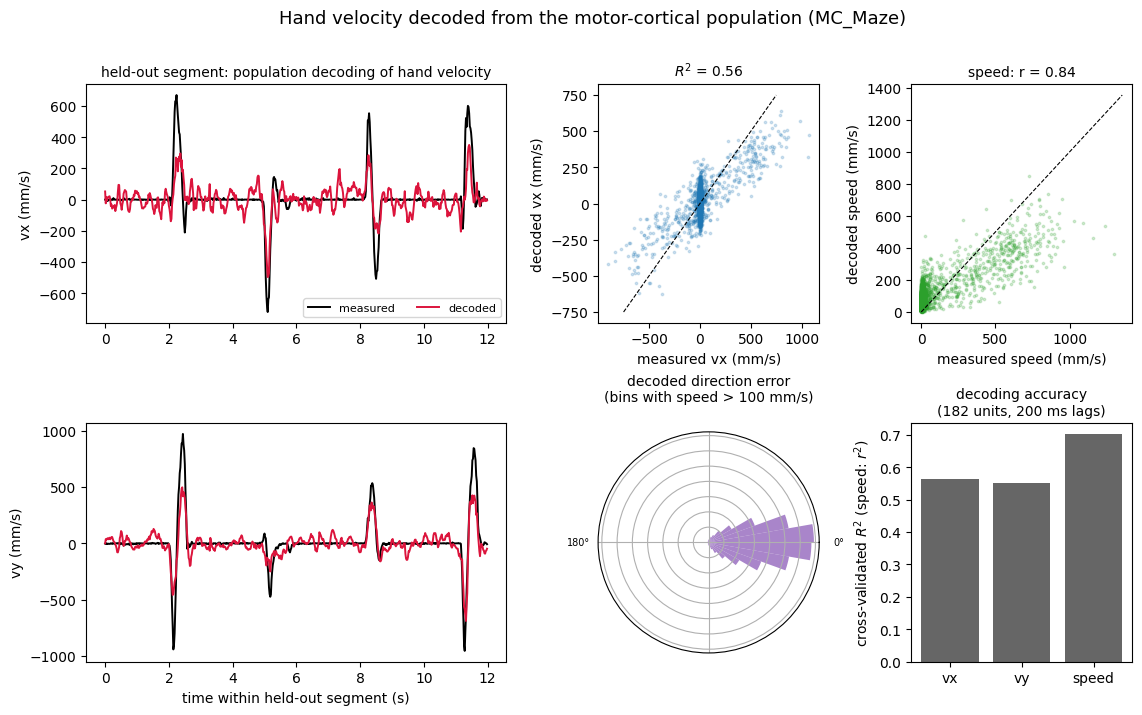

In [16]:
fig = plt.figure(figsize=(13.5, 7.5))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.32, width_ratios=[1.9, 1, 1])
seg = slice(2000, 2600)
for row, (lab, k) in enumerate([("vx", 0), ("vy", 1)]):
    ax = fig.add_subplot(gs[row, 0])
    tt = np.arange(seg.stop - seg.start) * BIN
    ax.plot(tt, Yvv[seg, k], "k", lw=1.4, label="measured")
    ax.plot(tt, pred[seg, k], color="crimson", lw=1.4, label="decoded")
    ax.set_ylabel("%s (mm/s)" % lab)
    if row == 0:
        ax.legend(fontsize=8, ncol=2)
        ax.set_title("held-out segment: population decoding of hand velocity", fontsize=10)
    else:
        ax.set_xlabel("time within held-out segment (s)")

sub = np.random.default_rng(0).choice(len(Yvv), 4000, replace=False)
ax = fig.add_subplot(gs[0, 1])
ax.scatter(Yvv[sub, 0], pred[sub, 0], s=3, alpha=0.2, color="tab:blue")
lim = np.percentile(np.abs(Yvv[:, 0]), 99.5)
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
ax.set_xlabel("measured vx (mm/s)")
ax.set_ylabel("decoded vx (mm/s)")
ax.set_title("$R^2$ = %.2f" % r2_dec[0], fontsize=10)

ax = fig.add_subplot(gs[0, 2])
ax.scatter(sp_true[sub], sp_pred[sub], s=3, alpha=0.2, color="tab:green")
ax.plot([0, sp_true.max()], [0, sp_true.max()], "k--", lw=0.8)
ax.set_xlabel("measured speed (mm/s)")
ax.set_ylabel("decoded speed (mm/s)")
ax.set_title("speed: r = %.2f" % r_speed, fontsize=10)

ax = fig.add_subplot(gs[1, 1], projection="polar")
h, e = np.histogram(ang_err, bins=np.linspace(-np.pi, np.pi, 37))
ax.bar(e[:-1], h, width=np.diff(e), align="edge", color="tab:purple", alpha=0.8)
ax.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""])
ax.set_yticklabels([])
ax.tick_params(labelsize=7)
ax.set_title("decoded direction error\n(bins with speed > 100 mm/s)", fontsize=10, pad=22)

ax = fig.add_subplot(gs[1, 2])
ax.bar(["vx", "vy", "speed"], [r2_dec[0], r2_dec[1], r_speed ** 2], color="0.4")
ax.set_ylabel("cross-validated $R^2$ (speed: $r^2$)")
ax.set_title("decoding accuracy\n(%d units, %d ms lags)"
             % (C_all.shape[1], 1000 * DECODE_LAGS[-1]), fontsize=10)
fig.suptitle("Hand velocity decoded from the motor-cortical population (MC_Maze)", fontsize=13)
fig.savefig("fig08_velocity_decoding.png", dpi=150, bbox_inches="tight")

## 8. Replication in a second dataset

MC_RTT (DANDI 000129) is a different monkey performing a self-paced
random-target task with no delay period and no trial structure. Running the
same continuous analysis there checks that the effects are not artefacts of one
session or one task design.

In [17]:
r = rl.load_mc_rtt()
rtt_units, rtt_vel, rtt_ep = r["units"], r["finger_vel"], r["epochs"]
print("MC_RTT: %d units, %.0f s of self-paced reaching" % (len(rtt_units), rtt_ep.tot_length()))

res_r = rl.continuous_velocity_tuning(rtt_units, rtt_vel, rtt_ep, bin_size=BIN,
                                      smooth_std=SMOOTH_STD, speed_min=SPEED_MIN,
                                      min_spikes=MIN_SPIKES)
print("units analysed: %d/%d" % (res_r["keep_u"].sum(), len(rtt_units)))
print("population-optimal lag: %+.0f ms" % (1000 * res_r["pop_lag"]))
print("linear velocity model: median R2 = %.3f (max %.3f)"
      % (np.nanmedian(res_r["r2_lin"]), np.nanmax(res_r["r2_lin"])))

Cm_r = np.asarray(res_r["counts"].values)[res_r["mask"]][:, res_r["keep_u"]].astype(float)
sp_r = res_r["speed"][res_r["mask"]]
rtt_speed_edges = np.linspace(SPEED_MIN, np.percentile(sp_r, 99), 9)
centres_r, gn_r, ga_r = rl.speed_gain_curves(Cm_r, res_r["theta"], sp_r, res_r["pd_cont"],
                                             BIN, speed_edges=rtt_speed_edges)
sl_near_r = np.array([slope(g, centres_r) for g in gn_r])
sl_away_r = np.array([slope(g, centres_r) for g in ga_r])
print("speed slope at PD %+.1f Hz per m/s, opposite %+.1f; PD steeper in %d/%d units"
      % (1000 * np.nanmean(sl_near_r), 1000 * np.nanmean(sl_away_r),
         np.sum(sl_near_r > sl_away_r), len(sl_near_r)))

MC_RTT: 130 units, 649 s of self-paced reaching


units analysed: 87/130
population-optimal lag: +80 ms
linear velocity model: median R2 = 0.031 (max 0.340)
speed slope at PD +8.0 Hz per m/s, opposite +0.8; PD steeper in 59/87 units


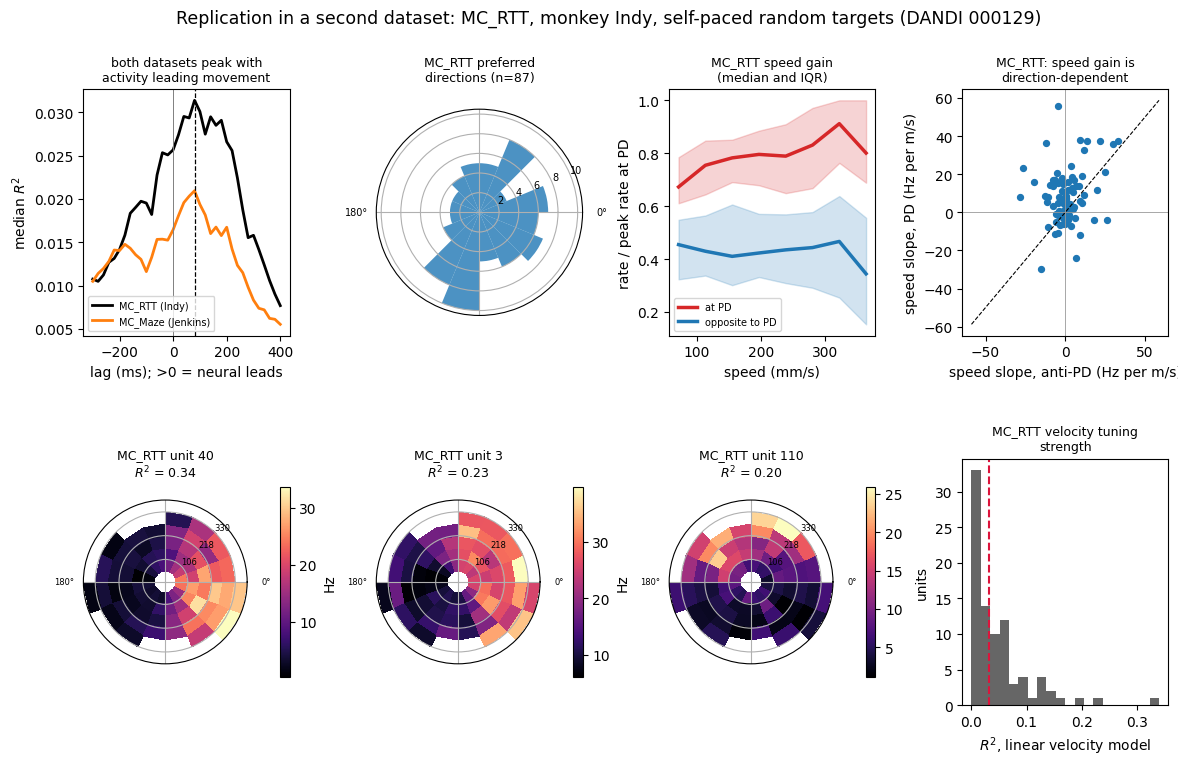

In [18]:
sp_edges_r = np.linspace(SPEED_MIN, np.percentile(sp_r, 99), 7)
tc_ds_r, _ = rl.rate_map_2d(Cm_r, res_r["theta"], sp_r, th_edges, sp_edges_r, BIN,
                            min_occupancy=30)
best_r = np.argsort(-np.nan_to_num(res_r["r2_lin"]))[:3]

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 4, hspace=0.5, wspace=0.42)

ax = fig.add_subplot(gs[0, 0])
ax.plot(1000 * res_r["lags"], res_r["pop_curve"], "k", lw=2, label="MC_RTT (Indy)")
ax.plot(1000 * res["lags"], res["pop_curve"], color="tab:orange", lw=2, label="MC_Maze (Jenkins)")
ax.axvline(0, color="0.5", lw=0.7)
ax.axvline(1000 * res_r["pop_lag"], color="k", ls="--", lw=0.9)
ax.set_xlabel("lag (ms); >0 = neural leads")
ax.set_ylabel("median $R^2$")
ax.set_title("both datasets peak with\nactivity leading movement", fontsize=9)
ax.legend(fontsize=7)

ax = fig.add_subplot(gs[0, 1], projection="polar")
h, e = np.histogram(res_r["pd_cont"], bins=np.linspace(-np.pi, np.pi, 17))
ax.bar(e[:-1], h, width=np.diff(e), align="edge", color="tab:blue", alpha=0.8)
ax.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""])
ax.tick_params(labelsize=7)
ax.set_title("MC_RTT preferred\ndirections (n=%d)" % res_r["keep_u"].sum(), fontsize=9, pad=20)

ax = fig.add_subplot(gs[0, 2])
nrm = np.nanmax(gn_r, axis=1, keepdims=True)
for g, c, lab in [(gn_r / nrm, "tab:red", "at PD"), (ga_r / nrm, "tab:blue", "opposite to PD")]:
    ax.plot(centres_r, np.nanmedian(g, 0), color=c, lw=2.5, label=lab)
    lo, hi = np.nanpercentile(g, [25, 75], axis=0)
    ax.fill_between(centres_r, lo, hi, color=c, alpha=0.2)
ax.set_xlabel("speed (mm/s)")
ax.set_ylabel("rate / peak rate at PD")
ax.set_title("MC_RTT speed gain\n(median and IQR)", fontsize=9)
ax.legend(fontsize=7)

ax = fig.add_subplot(gs[0, 3])
ax.scatter(1000 * sl_away_r, 1000 * sl_near_r, s=18, color="tab:blue")
lim = 1000 * np.nanmax(np.abs(np.r_[sl_near_r, sl_away_r])) * 1.05
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
ax.axhline(0, color="0.6", lw=0.6)
ax.axvline(0, color="0.6", lw=0.6)
ax.set_xlabel("speed slope, anti-PD (Hz per m/s)")
ax.set_ylabel("speed slope, PD (Hz per m/s)")
ax.set_title("MC_RTT: speed gain is\ndirection-dependent", fontsize=9)

for col, u in enumerate(best_r):
    ax = fig.add_subplot(gs[1, col], projection="polar")
    T, S = np.meshgrid(th_edges, sp_edges_r, indexing="ij")
    pc = ax.pcolormesh(T, S, np.ma.masked_invalid(tc_ds_r[:, :, u]), cmap="magma",
                       shading="flat")
    ax.set_thetagrids([0, 90, 180, 270], labels=["0°", "", "180°", ""])
    ax.set_rticks(np.round(sp_edges_r[1::2]).astype(int))
    ax.set_rlabel_position(45)
    ax.tick_params(labelsize=6)
    ax.set_title("MC_RTT unit %d\n$R^2$ = %.2f" % (res_r["uidx"][u], res_r["r2_lin"][u]),
                 fontsize=9, pad=16)
    plt.colorbar(pc, ax=ax, fraction=0.046, pad=0.16, label="Hz" if col < 2 else "")

ax = fig.add_subplot(gs[1, 3])
ax.hist(res_r["r2_lin"], bins=20, color="0.4")
ax.axvline(np.nanmedian(res_r["r2_lin"]), color="crimson", ls="--")
ax.set_xlabel("$R^2$, linear velocity model")
ax.set_ylabel("units")
ax.set_title("MC_RTT velocity tuning\nstrength", fontsize=9)

fig.suptitle("Replication in a second dataset: MC_RTT, monkey Indy, self-paced random targets "
             "(DANDI 000129)", fontsize=12.5)
fig.savefig("fig09_mc_rtt_replication.png", dpi=150, bbox_inches="tight")

## Summary

Both signatures of motor-cortical reach encoding are present and mutually
consistent in these data.

**Direction.** The large majority of units are significantly directionally
tuned during movement, and a cosine describes the tuning well. Preferred
directions tile the workspace close to uniformly, which is what makes the
population able to represent any reach direction. A directional signal is
already present during the delay period, before the hand moves, but the
preparatory preferred direction is only loosely related to the movement
preferred direction.

**Velocity.** Tuning is not to direction alone. Firing rate rises with speed for
movements toward the preferred direction and is flat or falls for movements
away from it, so speed acts as a direction-dependent gain rather than an
independent additive drive. The GLM comparison makes this quantitative: adding
a speed dimension to a direction-only model raises the cross-validated
pseudo-$R^2$ for nearly every unit, and the interaction model outperforms the
purely additive one.

**Timing.** The velocity fit peaks when neural activity leads the movement by
roughly 80 ms in both datasets, the expected sign and magnitude for a motor
command.

**Population.** Hand velocity can be decoded from the population with an $R^2$
above 0.5 per axis, and the decoded direction is within 45° of the true
direction for the large majority of moving time bins.

### Caveats

Single-unit $R^2$ values for the continuous velocity model are small (median
around 0.02), because restricting the analysis to movement bins removes the
largest source of rate variance, the difference between rest and movement.
Per-unit optimal lags are broadly distributed even though the population
estimate is sharp, so the 80 ms figure should be read as a population property
rather than a per-neuron one. Finally, MC_Maze contains both barrier-free and
maze trials, and the continuous analysis pools outward reaches with the return
movements between trials; the trial-based analysis, restricted to barrier-free
outward reaches, is the cleaner measurement of direction tuning, and the two
agree.

### References

- Georgopoulos, Kalaska, Caminiti & Massey (1982), *J Neurosci* 2:1527-1537.
- Moran & Schwartz (1999), *J Neurophysiol* 82:2676-2692.
- Churchland & Shenoy (2007), *J Neurophysiol* 97:4235-4257.
- Pei et al. (2021), Neural Latents Benchmark, arXiv:2109.04463.